<!-- #### **Router** -->

In [63]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

if os.environ.get('OPENAI_API_KEY'):
    print("Key is set")
else:
    raise ValueError('Key is not set in .env file')

llm_model = ChatOpenAI(model='gpt-4-0613')
llm_model.invoke('What is the colour of water').content

Key is set


'Pure water is colorless. However, it may appear blue or green due to impurities or depth.'

<!-- #### **Define LLM Schema** -->

In [64]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    topic: str
    category: Literal['twitter', 'insta','facebook', 'linkedin'] = Field(description='This will generate the cateory of the POST')


llm_model_schema = llm_model.with_structured_output(llm_schema)
llm_model_schema.invoke('what on Artifical Intelligent').category

'linkedin'

<!-- #### **Define GraphSchema** -->

In [65]:
from typing import TypedDict

class graph_schema(TypedDict):
    input: str
    topic: str
    category: str
    post: str

#### **Create Nodes**

In [66]:
def router(state:graph_schema):
    input = state['input']
    response = llm_model_schema.invoke(input)
    state['category'] = response.category
    state['topic'] = response.topic
    return state


def create_insta_post(state:graph_schema):
    topic = state['topic']
    category = state['category']
    post = llm_model.invoke(f'write a {category} post on {topic}').content
    state['post'] = post
    return state

def create_facebook_post(state:graph_schema):
    topic = state['topic']
    category = state['category']
    post = llm_model.invoke(f'write a {category} post on {topic}').content
    state['post'] = post
    return state

def create_twitter_post(state:graph_schema):
    topic = state['topic']
    category = state['category']
    post = llm_model.invoke(f'write a {category} post on {topic}').content
    state['post'] = post
    return state

def create_linkedin_post(state:graph_schema):
    topic = state['topic']
    category = state['category']
    post = llm_model.invoke(f'write a {category} post on {topic}').content
    state['post'] = post
    return state

In [67]:
def condition(state:graph_schema):
    if state['category'] =='insta':
        return  'create_insta_post'
    elif state['category'] == 'facebook':
        return 'create_facebook_post'
    elif state['category'] =='twitter':
        return 'create_twitter_post'
    elif state['category'] =='linkedin':
        return 'create_linkedin_post'
    else:
        raise ValueError('Invalid Category')
    

#### **State Graph**

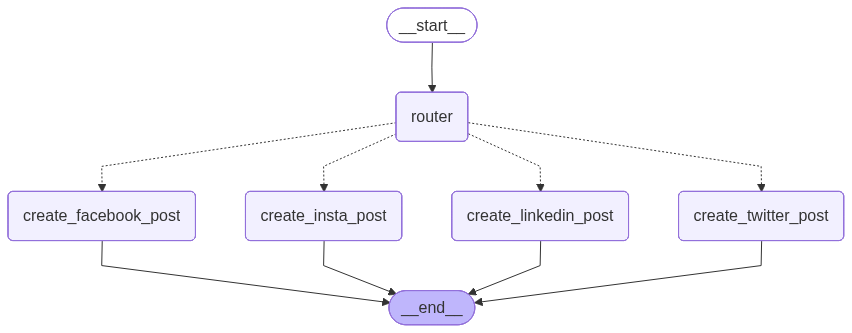

In [68]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)

## Add Nodes
graph.add_node('router', router)
graph.add_node('create_insta_post', create_insta_post)
graph.add_node('create_facebook_post', create_facebook_post)
graph.add_node('create_linkedin_post', create_linkedin_post)
graph.add_node('create_twitter_post', create_twitter_post)


## Add Edges
graph.add_edge(START, 'router')
graph.add_conditional_edges('router', condition, {
    'create_insta_post':'create_insta_post',
    'create_facebook_post':'create_facebook_post',
    'create_twitter_post':'create_twitter_post',
    'create_linkedin_post':'create_linkedin_post'
})
graph.add_edge('create_facebook_post', END)
graph.add_edge('create_insta_post', END)
graph.add_edge('create_twitter_post', END)
graph.add_edge('create_linkedin_post', END)

router_graph = graph.compile()

from IPython.display import Image
Image(router_graph.get_graph().draw_mermaid_png())

In [69]:
router_graph.invoke({
    'post': '',
    'input': 'Artifical Intelligent',
    'category':'',
    'topic':''
})

{'input': 'Artifical Intelligent',
 'topic': 'Artificial Intelligence',
 'category': 'linkedin',
 'post': "Excited about the monumental strides being made in the realm of Artificial Intelligence! AI has successfully permeated various sectors such as finance, healthcare, education, and transportation, showing its multiple implementation possibilities. It is indeed 'the electricity of our era' and will revolutionize the way we operate.\n\nThe versatility of AI systems to perform tasks that need human intelligence like learning, decision making, problem-solving, perception, and language translation, is truly phenomenal. As we integrate AI in our processes, let's ensure that we proactively address ethical considerations and societal implications\n\nAre you part of the AI revolution yet? Let's connect to discuss how AI can provide cutting-edge solutions for your business needs. #ArtificialIntelligence #Innovation #AIRevolution"}